<a href="https://colab.research.google.com/github/demsaid400-cpu/DI-BOOTCAMP/blob/main/Week5/Day1/Daily_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix

Explication :

* NumPy : manipulation des tableaux de données.
* Matplotlib/Seaborn : visualisation des images et graphiques.
* TensorFlow Keras : création et entraînement du réseau de neurones.
* Scikit-learn : calcul de la matrice de confusion.

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Explication :

Le dataset est divisé en :

* 60 000 images pour l’entraînement.
* 10 000 images pour le test.
Chaque image est de taille 28 * 28 pixels.

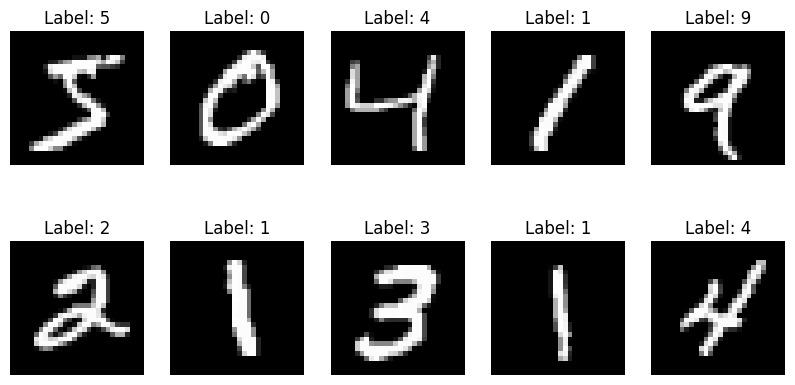

In [3]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.show()

In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

Les pixels vont de :
0 → noir
255 → blanc
Après normalisation :
0 → 0.0
255 → 1.0
Cela permet au réseau de neurones d’apprendre plus efficacement.

In [5]:
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [6]:
model = Sequential([
    Flatten(input_shape=(28,28)),

    Dense(128, activation="relu"),

    Dense(64, activation="relu"),

    Dense(10, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Architecture du modèle :
Image 28x28
      |
      ↓
Flatten
(784 neurones)
      |
      ↓
Couche cachée 1
128 neurones + ReLU
      |
      ↓
Couche cachée 2
64 neurones + ReLU
      |
      ↓
Sortie
10 neurones + Softmax
Rôle de chaque couche :

* Flatten transforme l’image 2D en vecteur de 784 pixels.
* Dense(128) apprend des caractéristiques simples.
* Dense(64) apprend des caractéristiques plus complexes.
* Softmax donne la probabilité que l’image soit chaque chiffre de 0 à 9.

In [7]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Signification :

Adam

* Algorithme qui ajuste automatiquement les poids du réseau.

Categorical Crossentropy

* Mesure l’erreur entre les prédictions et les vraies classes.

Accuracy

* Pourcentage de bonnes prédictions.

In [8]:
history = model.fit(
    X_train,
    y_train_cat,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9207 - loss: 0.2746 - val_accuracy: 0.9557 - val_loss: 0.1507
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9656 - loss: 0.1137 - val_accuracy: 0.9652 - val_loss: 0.1155
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9758 - loss: 0.0791 - val_accuracy: 0.9707 - val_loss: 0.0935
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9815 - loss: 0.0579 - val_accuracy: 0.9698 - val_loss: 0.1073
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9852 - loss: 0.0469 - val_accuracy: 0.9709 - val_loss: 0.1008
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9879 - loss: 0.0373 - val_accuracy: 0.9745 - val_loss: 0.0923
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9906 - loss: 0.0288 - val_accuracy: 0.9657 - val_loss: 0.1194
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9912 - loss: 0.0268

Ce qui se passe :

* 80 % des données servent à l’apprentissage.
* 20 % servent à la validation.
* Le réseau fait 10 passages complets sur les données.

À chaque époque, on observe :

* loss qui doit diminuer.
* accuracy qui doit augmenter.

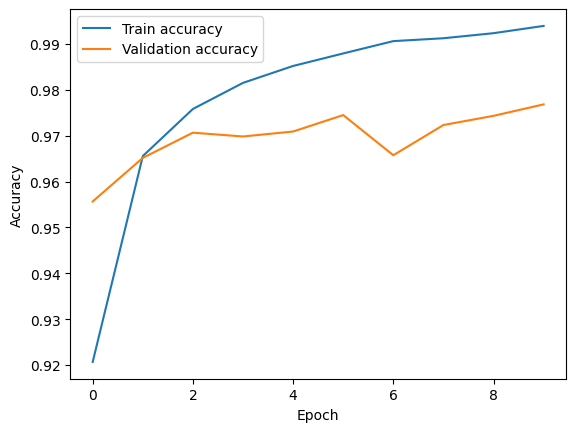

In [9]:
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [10]:
loss, accuracy = model.evaluate(
    X_test,
    y_test_cat
)

print("Accuracy :", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9770 - loss: 0.0970
Accuracy : 0.9769999980926514


In [11]:
predictions = model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Explication :

La fonction argmax() choisit la classe ayant la probabilité la plus élevée.

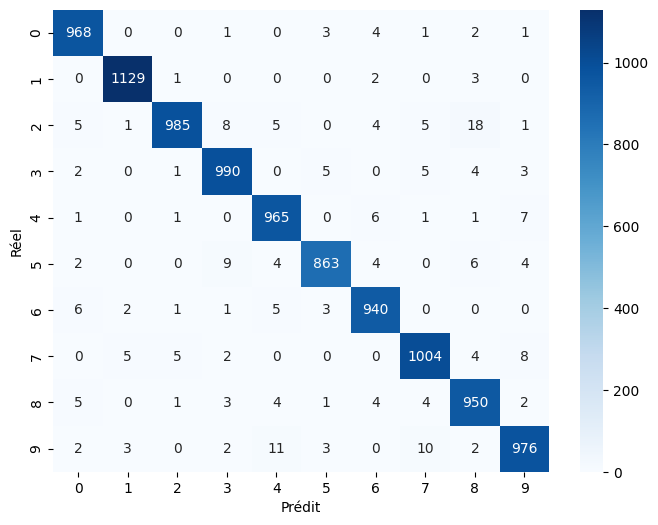

In [12]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

In [13]:
errors = cm.sum(axis=1) - np.diag(cm)

for i, error in enumerate(errors):
    print(f"Chiffre {i} : {error} erreurs")

Chiffre 0 : 12 erreurs
Chiffre 1 : 6 erreurs
Chiffre 2 : 47 erreurs
Chiffre 3 : 20 erreurs
Chiffre 4 : 17 erreurs
Chiffre 5 : 29 erreurs
Chiffre 6 : 18 erreurs
Chiffre 7 : 24 erreurs
Chiffre 8 : 24 erreurs
Chiffre 9 : 33 erreurs


In [14]:
Dense(256, activation="relu")

<Dense name=dense_3, built=False>

In [15]:
epochs=20

In [16]:
from tensorflow.keras.layers import Dropout

Dropout(0.2)

<Dropout name=dropout, built=True>